In [1]:
import pandas as pd
import numpy as np
import csv
import random
from pathlib import Path
from Bio import SeqIO
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold

Distribution of sequences in Train-Val-Test split

In [2]:
num_seqs = 141015
num_train = int(num_seqs*0.7)
num_val = int(num_seqs*0.1)
num_test = int(num_seqs*0.2)
print("Total number of sequences: ", num_seqs)
print(f"Training set: ", num_train, "Validation set: ", num_val, "Test set: ", num_test)


Total number of sequences:  141015
Training set:  98710 Validation set:  14101 Test set:  28203


Get clusters for Train-Val-test

In [3]:
def split_clusters_70_20_10(df, group_col="Cluster_number", label_col="Label",
                            random_state=42):
    """
    df: dataframe with at least [group_col, label_col]
    returns: (train_clusters, val_clusters, test_clusters)
    """

    # X is dummy, SGKF only really cares about y and groups
    X = np.zeros(len(df))
    y = df[label_col].values
    groups = df[group_col].values

    # ---- Outer split: 5 folds → pick 1 as test (~20%), rest (~80%) ----
    outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

    folds = []
    for _, test_idx in outer.split(X, y, groups):
        folds.append(test_idx)

    # Use first fold as test (they should all be similar size)
    test_idx = folds[0]
    remaining_idx = np.concatenate(folds[1:])   # ~80% left

    # ---- Inner split: split remaining 80% into 70% train + 10% val ----
    # 8 folds → 1 fold ≈ 10%, 7 folds ≈ 70%
    inner = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=random_state)
    train_inner_idx, val_inner_idx = next(
        inner.split(X[remaining_idx], y[remaining_idx], groups[remaining_idx])
    )

    train_idx = remaining_idx[train_inner_idx]
    val_idx   = remaining_idx[val_inner_idx]

    # ---- Map indices back to unique cluster IDs ----
    train_clusters = df.iloc[train_idx][group_col].unique()
    val_clusters   = df.iloc[val_idx][group_col].unique()
    test_clusters  = df.iloc[test_idx][group_col].unique()

    return train_clusters, val_clusters, test_clusters

def print_split_summary(df, train_clusters, val_clusters, test_clusters):
    train_df = df[df["Cluster_number"].isin(train_clusters)]
    val_df   = df[df["Cluster_number"].isin(val_clusters)]
    test_df  = df[df["Cluster_number"].isin(test_clusters)]

    print("Split distribution:")
    print(f"Train: {len(train_df)} sequences, {len(train_clusters)} clusters")
    print(f"Val: {len(val_df)} sequences, {len(val_clusters)} clusters")
    print(f"Test: {len(test_df)} sequences, {len(test_clusters)} clusters")

# ==== use it on your dataframe ====
df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_list90.csv")  

train_clusters, val_clusters, test_clusters = split_clusters_70_20_10(df)



# Save like you did before
pd.DataFrame({"Cluster_number": train_clusters}).to_csv(
    r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\train_clusters.csv",
    index=False
)
pd.DataFrame({"Cluster_number": val_clusters}).to_csv(
    r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\val_clusters.csv",
    index=False
)
pd.DataFrame({"Cluster_number": test_clusters}).to_csv(
    r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\test_clusters.csv",
    index=False
)
print_split_summary(df, train_clusters, val_clusters, test_clusters)


Split distribution:
Train: 98710 sequences, 91592 clusters
Val: 14102 sequences, 13079 clusters
Test: 28203 sequences, 26167 clusters


Fetch Cluster_number, total no. of sequences, and ditribution of labels from cluster_stats

In [7]:
train_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\val_clusters.csv")
train_cluster_list = train_df['Cluster_number'].tolist()

all_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_stats90.csv")

selected_labels_df = all_df[all_df['Cluster_number'].isin(train_cluster_list)][['Cluster_number', 'total_sequences', 'label_0', 'label_1']]
merge_df = train_df.merge(selected_labels_df, how='left', on='Cluster_number')

merge_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\val_clusters.csv", index=False)


Downsample test set

In [8]:
test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\test_clusters.csv")

filtered_df = test_df[(test_df['label_0'] >= 5) | (test_df['label_1'] >= 5)]
filtered_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\test_filtered_clusters.csv", index=False)


Make Test data from filtered dataset

In [9]:
random.seed(42)  # for reproducibility

# 1. Read only clusters you care about
f_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\test_filtered_clusters.csv")
test_cluster_ids = f_df['Cluster_number'].tolist()

cluster_dir = Path(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdrs_clusters_90")
output_csv = Path(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_filtered_data.csv")
output_csv.parent.mkdir(exist_ok=True)

csv_rows = []

for cid in test_cluster_ids:
    fasta_file = cluster_dir / f"cluster_{cid}.fasta"
    pos_seqs = []   # label 1
    neg_seqs = []   # label 0

    # 2. Parse FASTA and collect sequences per label
    for record in SeqIO.parse(fasta_file, "fasta"):
        header = record.description

        # Adjust regex to your header format; case-insensitive just in case
        match = re.search(r"\|Label=(\d)", header, re.IGNORECASE)
        if not match:
            continue

        label = int(match.group(1))
        if label == 1:
            pos_seqs.append((record.id, str(record.seq)))
        elif label == 0:
            neg_seqs.append((record.id, str(record.seq)))

    # 3. Only keep labels that have at least 5 sequences
    if len(pos_seqs) >= 5:
        selected_pos = random.sample(pos_seqs, 5)
    else:
        selected_pos = []  # ignore label 1 for this cluster

    if len(neg_seqs) >= 5:
        selected_neg = random.sample(neg_seqs, 5)
    else:
        selected_neg = []  # ignore label 0 for this cluster

    # If neither label has >=5, skip the cluster
    if not selected_pos and not selected_neg:
        print(f"Cluster {cid}: skipped (no label with ≥5 sequences)")
        continue

    # 4. Add rows for CSV
    for seq_id, seq in selected_pos:
        csv_rows.append([cid, seq_id, 1, seq])
    for seq_id, seq in selected_neg:
        csv_rows.append([cid, seq_id, 0, seq])

    print(
        f"Cluster {cid}: selected {len(selected_pos)} sequences with label=1 "
        f"and {len(selected_neg)} sequences with label=0"
    )

# 5. Write final CSV
with open(output_csv, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Cluster_name', 'Nanobody_id', 'Label', 'CDR_sequence'])
    writer.writerows(csv_rows)
 

Cluster 647: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 1347: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 18495: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 18499: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 18526: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 18539: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 20524: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 47336: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 49725: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 50825: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 52933: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 52938: selected 5 sequences with label=1 and 0 sequences with label=0
Cluster 52948: selected 5 sequences with label=1 and 0 sequences wi

Get the not filtered test clusters 

In [10]:
filtered_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\test_filtered_clusters.csv")
test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\test_clusters.csv")
filter_cluster_ids = filtered_df['Cluster_number'].tolist()

selected_clusters_df = test_df[~test_df['Cluster_number'].isin(filter_cluster_ids)][['Cluster_number', 'total_sequences', 'label_0', 'label_1']]
selected_clusters_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\test_clusters_normal.csv", index=False)

Make the dataset from clusters list

In [13]:
f_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\val_clusters.csv")
test_cluster_ids = f_df['Cluster_number'].tolist()

cluster_dir = Path(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdrs_clusters_90")
output_csv = Path(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\val_data.csv")
output_csv.parent.mkdir(exist_ok=True)

csv_rows = []
for cid in test_cluster_ids:
    fasta_file = cluster_dir / f"cluster_{cid}.fasta"
    pos_seqs = []
    neg_seqs = []

    for record in SeqIO.parse(fasta_file, "fasta"):
        header = record.description
        label = None
        
        match = re.search(r"\|Label=(\d)", header)
        if match:
            label = int(match.group(1))
            if label == 1:
                pos_seqs.append((record.id, str(record.seq)))
            elif label == 0:
                neg_seqs.append((record.id, str(record.seq)))

    for seq_id, seq in pos_seqs:
        csv_rows.append([cid, seq_id, 1, seq])
    for seq_id, seq in neg_seqs:
        csv_rows.append([cid, seq_id, 0, seq])

    print(f"Cluster {cid}: selected {len(pos_seqs)} positive sequences and {len(neg_seqs)} negative sequences")

with open(output_csv, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Cluster_name', 'Nanobody_id', 'Label', 'CDR_sequence'])
    writer.writerows(csv_rows)
  

Cluster 32: selected 0 positive sequences and 1 negative sequences
Cluster 45: selected 1 positive sequences and 0 negative sequences
Cluster 49: selected 0 positive sequences and 1 negative sequences
Cluster 276: selected 1 positive sequences and 0 negative sequences
Cluster 363: selected 0 positive sequences and 1 negative sequences
Cluster 365: selected 0 positive sequences and 1 negative sequences
Cluster 395: selected 0 positive sequences and 2 negative sequences
Cluster 442: selected 0 positive sequences and 1 negative sequences
Cluster 488: selected 0 positive sequences and 1 negative sequences
Cluster 506: selected 0 positive sequences and 1 negative sequences
Cluster 514: selected 0 positive sequences and 1 negative sequences
Cluster 567: selected 0 positive sequences and 1 negative sequences
Cluster 606: selected 0 positive sequences and 1 negative sequences
Cluster 618: selected 0 positive sequences and 1 negative sequences
Cluster 760: selected 2 positive sequences and 0 ne

Merge filtered and normal test set 

In [14]:
filtered_test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_filtered_data.csv")
normal_test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_normal_data.csv")

combined_df = pd.concat([filtered_test_df, normal_test_df], ignore_index=True)
combined_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_combined_data.csv", index=False)

Graphs for Labels of Train-Val-Test split

C:\Users\ankit\AppData\Local\Temp\ipykernel_27576\1802673395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=train_label_counts.index, y=train_label_counts.values, palette="Blues")


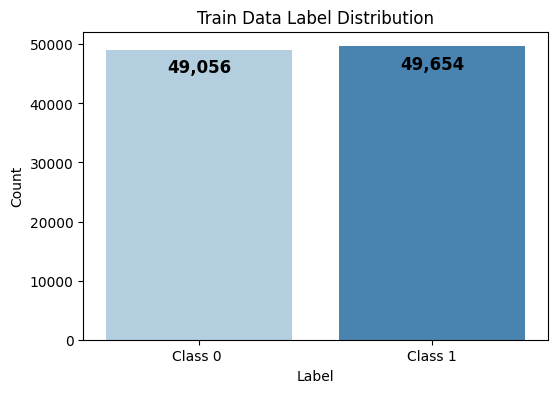

In [16]:
train_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\train_data.csv")
train_label_counts = train_df["Label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=train_label_counts.index, y=train_label_counts.values, palette="Blues")
for i, v in enumerate(train_label_counts.values):
    ax.text(
        i, v - (0.03 * v), f"{v:,}", ha='center', va='top', color='black', fontsize=12, fontweight='bold'
    )
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Train Data Label Distribution')
plt.xticks([0, 1], labels=["Class 0 ", "Class 1"])
plt.savefig(r"D:\Thesis EGFR dataset\Figures\train_data_label_distribution 90.png", dpi=300)
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_27576\2227084651.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=val_label_counts.index, y=val_label_counts.values, palette="Reds")


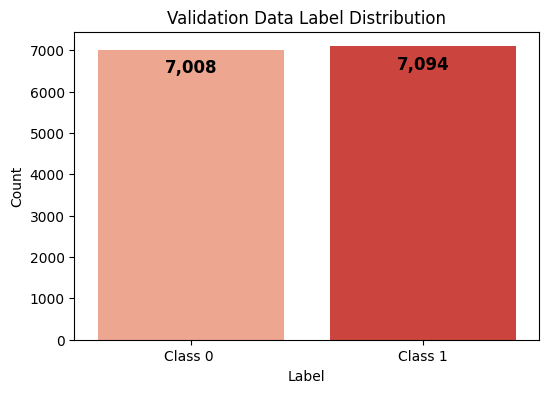

In [18]:
val_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\val_data.csv")
val_label_counts = val_df["Label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=val_label_counts.index, y=val_label_counts.values, palette="Reds")
for i, v in enumerate(val_label_counts.values):
    ax.text(
        i, v - (0.03 * v), f"{v:,}", ha='center', va='top', color='black', fontsize=12, fontweight='bold'
    )
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Validation Data Label Distribution')
plt.xticks([0, 1], labels=["Class 0 ", "Class 1"])
plt.savefig(r"D:\Thesis EGFR dataset\Figures\val_data_label_distribution 90.png", dpi=300)
plt.show()

28097


C:\Users\ankit\AppData\Local\Temp\ipykernel_27576\1742824671.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=test_label_counts.index, y=test_label_counts.values, palette="Greens")


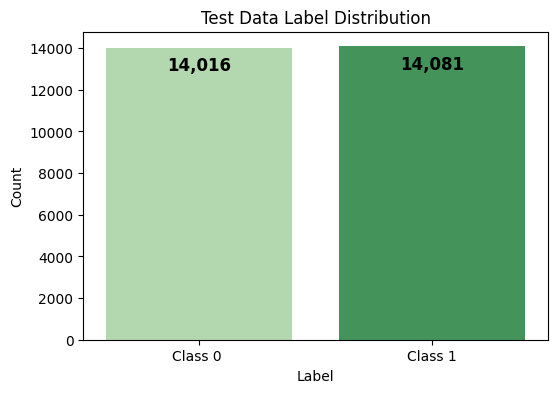

In [20]:
test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_combined_data.csv")
print(len(test_df))
test_label_counts = test_df["Label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=test_label_counts.index, y=test_label_counts.values, palette="Greens")
for i, v in enumerate(test_label_counts.values):
    ax.text(
        i, v - (0.03 * v), f"{v:,}", ha='center', va='top', color='black', fontsize=12, fontweight='bold'
    )
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Test Data Label Distribution')
plt.xticks([0, 1], labels=["Class 0 ", "Class 1"])
plt.savefig(r"D:\Thesis EGFR dataset\Figures\test_data_label_distribution 90.png", dpi=300)
plt.show()